# 26.2 · Frozen backbones and new heads

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain frozen backbones and new heads using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[25 · Image Classification](../../25-image-classification/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Transfer learning starts from useful learned features and adapts them to a new task. This can reduce data and training requirements, but success depends on how source and target data relate. Frozen features and fine-tuning answer different experimental questions.

## 2. Intuition

Feature extraction freezes backbone parameters and trains a replacement classifier. Freezing requires controlling requires_grad and sometimes layer mode: batch-normalization running statistics can change even when parameter gradients are disabled. The experiment measures actual backbone parameter changes instead of assuming the freeze succeeded.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 26
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
h=f_{\theta}(x),\qquad z=W h+b
$$

x is an image, fθ the backbone, h its feature vector and W,b the new head. Frozen transfer changes W and b while holding θ fixed. With h=[2,1], W=[0.5,−1] and b=0.2, the score is 0.2.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
features = np.array([2.0, 1.0])
weights = np.array([0.5, -1.0])
score = weights @ features + 0.2
assert np.isclose(score, 0.2)
print(score)

0.2


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The lab snapshots feature parameters, trains the target head or full network and computes the maximum feature change. The reported source model is locally trained, not ImageNet pretrained.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def transfer(lesson, seed, amount):
    configure(seed)
    x, y, _ = shape_data(96, seed=seed)
    test_x, test_y, _ = shape_data(30, seed=seed + 1000)
    model = TinyCNN()
    pretrain = train_supervised(model, x, y, epochs=3, seed=seed)
    source_weights = {
        name: parameter.detach().clone() for name, parameter in model.features.named_parameters()
    }
    for parameter in model.features.parameters():
        parameter.requires_grad = lesson == 2
    model.head = nn.Linear(16 * 3 * 3, 3)
    shifted = (x * 0.7 + 0.15).clamp(0, 1)
    target_history = train_supervised(model, shifted, y, epochs=3, lr=0.01 * amount, seed=seed)
    changed = max(
        float((p - source_weights[name]).abs().max())
        for name, p in model.features.named_parameters()
    )
    with torch.no_grad():
        prediction = model((test_x * 0.7 + 0.15).clamp(0, 1)).argmax(1)
    return Result(
        "26 · Feature extraction versus fine-tuning",
        {"Source domain": x[0, 0].numpy(), "Shifted domain": shifted[0, 0].numpy()},
        curves={"Source training loss": pretrain, "Target adaptation loss": target_history},
        metrics={
            "feature_max_parameter_change": changed,
            "held_out_target_accuracy": float((prediction == test_y).float().mean()),
            "backbone_frozen": lesson != 2,
        },
        notes="Pretraining is performed locally on generated shapes; this is not ImageNet-pretrained transfer.",
    )

{
  "feature_max_parameter_change": 0.0,
  "held_out_target_accuracy": 0.36666667461395264,
  "backbone_frozen": true
}
Pretraining is performed locally on generated shapes; this is not ImageNet-pretrained transfer.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/models.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.models import train_supervised

display(Code(inspect.getsource(train_supervised), language="python"))

def train_supervised(model, x, y, epochs=6, batch_size=16, lr=0.01, seed=42, segmentation=False):
    """Training-only loop. Caller owns an independent held-out set and evaluation."""
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(x, y), batch_size=batch_size, shuffle=True, generator=generator
    )
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    history = []
    model.train()
    for _ in range(epochs):
        total = 0
        for batch, target in loader:
            optimizer.zero_grad(set_to_none=True)
            prediction = model(batch)
            loss = (
                F.binary_cross_entropy_with_logits(prediction, target)
                if segmentation
                else F.cross_entropy(prediction, target)
            )
            loss.backward()
            optimizer.step()
            total += float(loss.detach()) * len(batch)
        history.append(total / len(x))
    model.eval()
    return history

## 8. Experiment

Vary target brightness and compare frozen features with fine-tuning at two learning rates using an unchanged test set.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "feature_max_parameter_change": 0.0,
    "held_out_target_accuracy": 0.36666667461395264,
    "backbone_frozen": true
  },
  "second_seed": {
    "feature_max_parameter_change": 0.0,
    "held_out_target_accuracy": 0.46666666865348816,
    "backbone_frozen": true
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

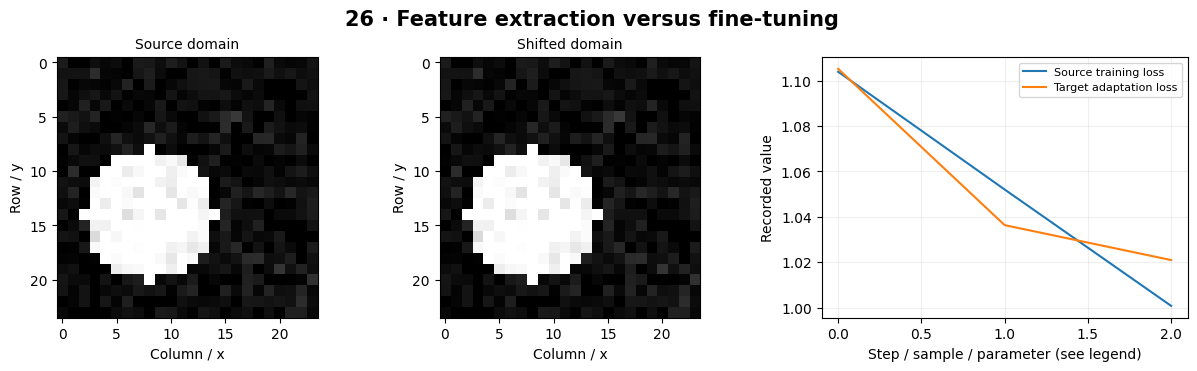

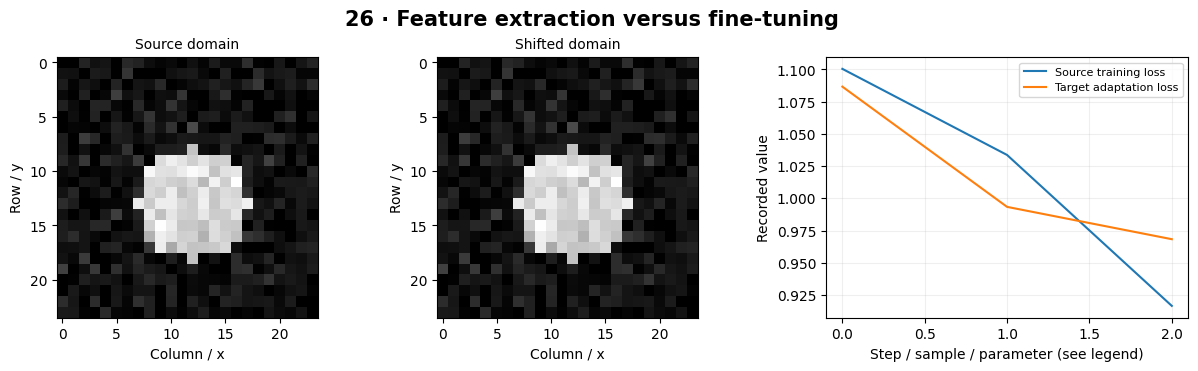

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Industrial Defect Classifier**. Compare frozen features against controlled fine-tuning. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Replacing the head without matching the label map can silently swap class meanings. Pretraining data may overlap an evaluation set.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Vary target brightness and compare frozen features with fine-tuning at two learning rates using an unchanged test set.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Adapt a classifier to a small industrial dataset and compare scratch, frozen-backbone and fine-tuned baselines under the same split.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Feature extraction freezes backbone parameters and trains a replacement classifier. Freezing requires controlling requires_grad and sometimes layer mode: batch-normalization running statistics can change even when parameter gradients are disabled. The experiment measures actual backbone parameter changes instead of assuming the freeze succeeded.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Fine-tuning under domain shift** in this chapter.

[Primary reference](https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)